In [1]:
import pydicom
from pathlib import Path
import os
import napari
import cv2
import json
from scipy.ndimage import rotate, shift, zoom
from functools import lru_cache
from scipy.interpolate import RegularGridInterpolator

SPECT shape: (256, 128, 128)
SPECT min/max antes de resample: -4.0 667.0
SPECT spacing: (4.419844, 4.419844, 4.41984)
SPECT origin: (-278.560094, -319.560094, 563.53011)
-----------------
SPECT shape: (256, 128, 128)
CT shape: (606, 512, 512)
slice_z_positions_spect (primeros 5/últimos 5): [563.53011 567.94995 572.36979 576.78963 581.20947] / [1672.90995 1677.32979 1681.74963 1686.16947 1690.58931]
ct_z_positions (primeros 5/últimos 5): [-378.350006 -377.100006 -375.850006 -374.600006 -373.350006] / [372.899994 374.149994 375.399994 376.649994 377.899994]
Offset Z aplicado: -941.880116
SPECT resampleado min/max: -3.7738433970461083 666.6091731827396
SPECT resampleado y escalado min/max: -3.70674183390196 664.0017628700623
SPECT final shape: (606, 512, 512)
SPECT normalizado entre 0 y 1


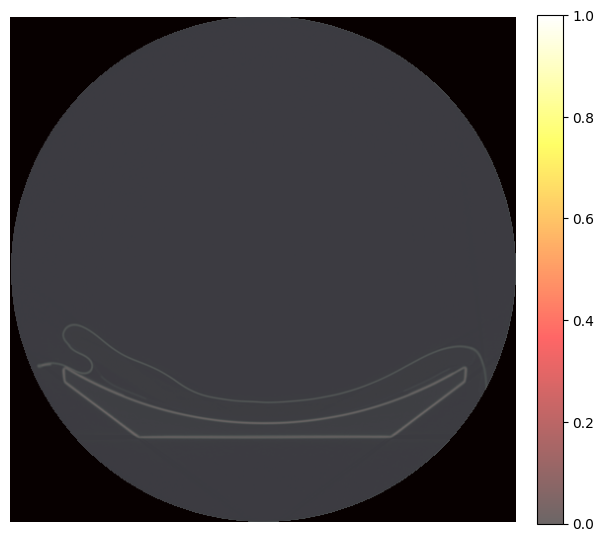

In [ ]:
import tkinter as tk
from tkinter import ttk, filedialog, messagebox
from datetime import datetime
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import pydicom
import os

# -------------------- VARIABLES GLOBALES --------------------

archivos_ct = []      # Lista de archivos CT
archivo_spect = ""    # Archivo único SPECT

fig = None
ax = None
canvas = None

cbar = None        # Barra de colores asociada al SPECT
im_ct = None       # Objeto de imagen de Matplotlib para CT
im_spect = None    # Objeto de imagen de Matplotlib para SPECT

num_slices_ct = 1    # Numero de cortes de la imagen CT
num_slices_spect = 1 # Numero de cortes de la imagen SPECT
slice_ct = None  # Slider único

ct_img_sitk = None       # Imagen ct leída con SimplelTK 
spect_img_sitk = None    # Imagen spect leída con SimplelTK
spect_on_ct_sitk = None  # Imagen spect ya resampleada al grid del CT

ct_np = None    # Versión de la imagen ct en un array de Numpy
spect_np = None # Versión de la imagen spect en un array de Numpy

# -------------------- FUNCIONES --------------------

def seleccionar_fichero_spect():
    """Seleccionar archivo SPECT y convertir a numpy"""
    global archivo_spect, spect_img_sitk, spect_np, num_slices_spect 
    # global --> los cambios que se hagan dentro de la función afectarán a estas variables fuera de la función

    ruta = filedialog.askopenfilename(
        title="Seleccionar fichero SPECT",
        filetypes=[("Archivos DICOM", "*.dcm")]
    )
    if not ruta:
        return

    archivo_spect = ruta # Se guarda la ruta del archivo en la variable global
    entry_spect.delete(0, tk.END) # Borra cualquier texto que hubiera antes en el campo de texto de la interfaz
    entry_spect.insert(0, ruta)   # Inserta la ruta del archivo

    # Leer SPECT
    spect_img_sitk = sitk.ReadImage(ruta, sitk.sitkFloat32) # Lee el archivo spect con SimplelTK y se guarda en la variable
    spect_np = sitk.GetArrayFromImage(spect_img_sitk) # Convierte la imagen en un array de Numpy --> spect_np = [slices, altura, anchura]

    num_slices_spect = spect_np.shape[0] # Guarda el número de cortes de la imagen (slices)
    slice_ct.set(num_slices_spect // 2)  # Inicializamos slider en el corte central

    # Inicializar figura
    if fig is None:
        inicializar_figura()

    # Si ya hay CT, resampleamos SPECT
    if ct_img_sitk is not None:
        resamplear_spect_a_ct()

    actualizar_overlay()

def seleccionar_ct():
    """Seleccionar carpeta con cortes CT"""
    global archivos_ct, ct_img_sitk, ct_np, num_slices_ct

    carpeta = filedialog.askdirectory(title="Seleccionar carpeta con cortes CT (.dcm)")
    if not carpeta:
        return

    archivos_ct = carpeta
    entry_ct.delete(0, tk.END)
    entry_ct.insert(0, carpeta)

    reader = sitk.ImageSeriesReader() # Crea un lector de imagenes DICOM de SimplelTK
    series_ids = reader.GetGDCMSeriesIDs(carpeta) # Obtiene los IDs de todas las series DICOM
    file_names = reader.GetGDCMSeriesFileNames(carpeta, series_ids[0]) # obtiene los nombres
    reader.SetFileNames(file_names) 
    ct_img_sitk = reader.Execute()
    archivos_ct = file_names # Sobrescribe la variable archivos_ct con la lista de archivos individuales de la serie, en lugar de la ruta de la carpeta.

    ct_np = sitk.GetArrayFromImage(ct_img_sitk)
    num_slices_ct = ct_np.shape[0]
    slice_ct.set(num_slices_ct // 2)
    ct_slider.config(to=num_slices_ct - 1) # Ajusta el rango del slider al num max

    # Leer posiciones Z de cada slice del CT usando tags
    ct_z_positions = []
    for f in file_names:
        ds = pydicom.dcmread(f)
        if (0x0020, 0x1041) in ds:  # SliceLocation
            ct_z_positions.append(float(ds.SliceLocation))
        else:  # fallback a ImagePositionPatient
            ct_z_positions.append(ds.ImagePositionPatient[2])
    ct_z_positions = np.array(ct_z_positions)
    globals()['ct_z_positions'] = ct_z_positions

    # Resamplear SPECT si ya fue cargado
    if spect_img_sitk is not None:
        resamplear_spect_a_ct()

    actualizar_overlay()

def calcular_normalizacion_global():
    """Normaliza todo el SPECT entre 0 y 1"""
    global spect_np
    if spect_np is None:
        return
    min_val = np.min(spect_np)
    max_val = np.max(spect_np)
    if max_val > min_val:
        spect_np = (spect_np - min_val) / (max_val - min_val)
    else:
        spect_np = np.zeros_like(spect_np)  # por si todos los valores son iguales
    print(f"SPECT normalizado entre 0 y 1")


def resamplear_spect_a_ct():
    """Resamplea el SPECT al grid del CT mostrando información detallada"""
    global spect_on_ct_sitk, spect_np, num_slices_spect

    if spect_img_sitk is None or ct_img_sitk is None:
        print("⚠ SPECT o CT no cargados")
        return

    spect_np = sitk.GetArrayFromImage(spect_img_sitk)  # shape = [Z, Y, X]
    spacing = spect_img_sitk.GetSpacing()  # (X, Y, Z)
    origin = spect_img_sitk.GetOrigin()    # (X, Y, Z)

    slice_z_positions_spect = origin[2] + np.arange(spect_np.shape[0]) * spacing[2]
    global ct_z_positions

    # --- INFORMACIÓN DE DEPURACIÓN ---
    print("SPECT shape:", spect_np.shape)
    print("CT shape:", ct_np.shape)
    print("slice_z_positions_spect (primeros 5/últimos 5):", slice_z_positions_spect[:5], "/", slice_z_positions_spect[-5:])
    print("ct_z_positions (primeros 5/últimos 5):", ct_z_positions[:5], "/", ct_z_positions[-5:])

    # Ajuste de offset
    offset_z = ct_z_positions[0] - slice_z_positions_spect[0]
    slice_z_positions_spect_aligned = slice_z_positions_spect + offset_z
    print("Offset Z aplicado:", offset_z)

    from scipy.interpolate import interp1d
    interp_func = interp1d(slice_z_positions_spect_aligned, spect_np, axis=0,
                           bounds_error=False, fill_value=0.0)
    spect_resampled_np = interp_func(ct_z_positions)

    # Reescalar X/Y si difiere del CT
    ct_size = ct_np.shape  # (Z, Y, X)
    zoom_factors = (ct_size[1]/spect_resampled_np.shape[1],
                    ct_size[2]/spect_resampled_np.shape[2])
    import scipy.ndimage
    spect_resampled_np = np.array([scipy.ndimage.zoom(s, zoom_factors, order=1)
                                   for s in spect_resampled_np])

    print("SPECT resampleado y escalado min/max:", np.min(spect_resampled_np), np.max(spect_resampled_np))
    print("SPECT final shape:", spect_resampled_np.shape)

    spect_np = spect_resampled_np
    num_slices_spect = spect_np.shape[0]

    calcular_normalizacion_global()


def guardar_datos():
    """Valida y muestra los datos introducidos"""
    fecha = entry_fecha.get()
    actividad = entry_actividad.get()

    if not archivo_spect or not archivos_ct or not fecha or not actividad:
        messagebox.showwarning("Campos incompletos", "Complete todos los campos y seleccione SPECT y CT.")
        return

    try:
        datetime.strptime(fecha, "%d/%m/%Y")
    except ValueError:
        messagebox.showerror("Error de formato", "La fecha debe tener el formato dd/mm/aaaa.")
        return

    resumen = (
        f"Datos introducidos correctamente\n\n"
        f"Archivo SPECT: {archivo_spect}\n"
        f"Carpeta CT: {entry_ct.get()} ({len(archivos_ct)} cortes)\n"
        f"Fecha: {fecha}\n"
        f"Actividad: {actividad} MBq"
    )
    messagebox.showinfo("Resumen", resumen)

# -------------------- VISUALIZACIÓN --------------------

vmin_spect = None
vmax_spect = None

def inicializar_figura():
    """Crea la figura y canvas de Matplotlib"""
    global fig, ax, canvas
    fig, ax = plt.subplots(figsize=(5,5))
    canvas = FigureCanvasTkAgg(fig, master=frame_spect)
    canvas.get_tk_widget().pack(fill="both", expand=True)
    ax.axis("off")

def actualizar_overlay():
    """Actualiza la visualización CT+SPECT con normalización 0-1"""
    global im_ct, im_spect, cbar, canvas

    if spect_np is None or ct_np is None:
        return

    z = int(slice_ct.get())  # Slice actual

    if im_ct is None or im_spect is None:
        im_ct = ax.imshow(ct_np[z], cmap="bone")
        im_spect = ax.imshow(spect_np[z], cmap="hot", alpha=0.6, vmin=0, vmax=1)
        ax.axis("off")
        if cbar is None:
            cbar = fig.colorbar(im_spect, ax=ax, fraction=0.046, pad=0.04)
    else:
        im_ct.set_data(ct_np[z])
        im_spect.set_data(spect_np[z])
        im_spect.set_clim(0, 1)  # escala 0-1
    canvas.draw_idle()


# -------------------- INTERFAZ --------------------

root = tk.Tk()
root.title("Interfaz de calibración")
root.geometry("1300x700")
root.resizable(False, False)

spect_img_sitk = None
spect_on_ct_sitk = None
ct_img_sitk = None
spect_np = None
ct_np = None

slice_ct = tk.IntVar(value=0)

# Estilos
style = ttk.Style()
style.configure("TLabel", font=("Calibri", 11))
style.configure("TButton", font=("Calibri", 10))
style.configure("TEntry", font=("Calibri", 10))

# Frames
frame_controles = ttk.Frame(root)
frame_controles.grid(row=0, column=0, sticky="ns", padx=10, pady=10)

frame_spect_container = ttk.LabelFrame(root, text="SPECT/CT")
frame_spect_container.grid(row=0, column=1, sticky="nsew", padx=10, pady=10)

root.columnconfigure(0, weight=0)
root.columnconfigure(1, weight=1)
root.rowconfigure(0, weight=1)

frame_spect = ttk.Frame(frame_spect_container)
frame_spect.pack(fill="both", expand=True)
frame_spect_container.config(width=500, height=500)
frame_spect_container.grid_propagate(False)

# Entradas y botones
ttk.Label(frame_controles, text="Fichero SPECT:").grid(row=0, column=0, sticky="w", pady=4)
entry_spect = ttk.Entry(frame_controles, width=35)
entry_spect.grid(row=0, column=1, pady=4)
ttk.Button(frame_controles, text="Examinar...", command=seleccionar_fichero_spect).grid(row=0, column=2, padx=5, pady=4)

ttk.Label(frame_controles, text="Carpeta CT:").grid(row=1, column=0, sticky="w", pady=4)
entry_ct = ttk.Entry(frame_controles, width=35)
entry_ct.grid(row=1, column=1, pady=4)
ttk.Button(frame_controles, text="Examinar...", command=seleccionar_ct).grid(row=1, column=2, padx=5, pady=4)

ttk.Label(frame_controles, text="Fecha de adquisición (dd/mm/aaaa):").grid(row=2, column=0, sticky="w", pady=4)
entry_fecha = ttk.Entry(frame_controles, width=20)
entry_fecha.grid(row=2, column=1, pady=4, sticky="w")

ttk.Label(frame_controles, text="Actividad (MBq):").grid(row=3, column=0, sticky="w", pady=4)
entry_actividad = ttk.Entry(frame_controles, width=20)
entry_actividad.grid(row=3, column=1, pady=4, sticky="w")

ttk.Button(frame_controles, text="Guardar datos", command=guardar_datos).grid(row=4, column=1, pady=12, sticky="w")

# Slider único
ttk.Label(frame_controles, text="Slice CT/SPECT").grid(row=5, column=0, sticky="w", pady=4)
ct_slider = ttk.Scale(frame_controles, from_=0, to=0, variable=slice_ct,
                     command=lambda e: actualizar_overlay())
ct_slider.grid(row=5, column=1, columnspan=2, sticky="ew")

# -------------------- EJECUCIÓN --------------------
root.mainloop()


In [11]:
file_path = r"C:\Users\gervi\OneDrive - Universidad Complutense de Madrid (UCM)\MASTER\SEGUNDO CUATRI\TFM\Imagenes prueba\Tomo4FOV_Lu177peak_IRACSC001_DS.dcm"
ds = pydicom.dcmread(file_path)
image = ds.pixel_array

print(ds)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 210
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Nuclear Medicine Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.840.113619.2.281.40117.101394071.1759825124.8835020
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.840.113619.6.281
(0002,0013) Implementation Version Name         SH: 'Xeleris 4.0117'
(0002,0016) Source Application Entity Title     AE: 'HDOCXELERIS1'
-------------------------------------------------
(0008,0000) Group Length                        UL: 562
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['DERIVED', 'PRIMARY', 'RECON TOMO', 'EMISSION']
(0008,0012) Instance Creation Date              DA: '20251007'
(0008,0013) Insta

In [41]:
folder_path = r"C:\Users\gervi\OneDrive - Universidad Complutense de Madrid (UCM)\MASTER\SEGUNDO CUATRI\TFM\Imagenes prueba\CT"

# Listar y leer cada archivo .dcm
for filename in os.listdir(folder_path):
    if filename.endswith(".dcm"):
        path = os.path.join(folder_path, filename)
        ds = pydicom.dcmread(path)

image = ds.pixel_array

print(ds)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 210
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.840.113619.2.281.40117.101394071.1759825130.78793050
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.840.113619.6.281
(0002,0013) Implementation Version Name         SH: 'Xeleris 4.0117'
(0002,0016) Source Application Entity Title     AE: 'HDOCXELERIS1'
-------------------------------------------------
(0008,0000) Group Length                        UL: 530
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['DERIVED', 'PRIMARY', 'AXIAL']
(0008,0012) Instance Creation Date              DA: '20251007'
(0008,0013) Instance Creation Time             